# RQ11 — Absolute Classification vs Controlled Ranking

## Research question

> Should each one-digit movement be classified independently as true/false, or should the ten movements in one controlled scan be ranked against each other?

RQ10 rejected Binding-first because a unique next-wheel label did not remain mechanically well-defined throughout the hierarchy. RQ11 therefore changes the **decision unit**.

### Do not confuse RQ11 with RQ7

- **RQ7** asked which *feature representation* generalises better: Absolute 695-D features or within-scan normalised features.
- **RQ11** keeps the **same Absolute representation, same LOPO models, same folds and same candidate scores** and changes only the *decision rule*.

This isolates the task-formulation question.

### Two decision rules

**Absolute classification**

Each candidate is judged independently.

The frozen logistic `decision_function` is thresholded at its natural boundary:

`score >= 0 → true-gate-like`

A 10-candidate scan can therefore produce:

- zero positive candidates;
- exactly one positive candidate;
- multiple positive candidates.

For the physical task, an absolute classification is considered a complete correct decision only when **exactly one** candidate is positive and that candidate is the true digit.

**Controlled relative ranking**

The same ten scores are kept together as one decision and sorted.

The candidate with the highest score is selected; Top-2 and Top-3 remain available as uncertainty information.

This always produces one ranked decision without requiring the score scale to be globally calibrated across scans.

### Data

The input is the frozen Absolute LOPO candidate-score table already generated in RQ7:

- seven passwords;
- W1, W2 and W4;
- CW and CCW treated as known domains;
- A/B repeats retained;
- 840 complete decisions;
- 8,400 candidates.

No model is retrained in RQ11.

## 1. Load the frozen candidate scores

In [1]:
from google.colab import drive
from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display

drive.mount(
    "/content/drive"
)

MYDRIVE = Path(
    "/content/drive/MyDrive"
)

PROJECT_ROOT = (
    MYDRIVE
    / "Padlock_Reproduction_v1"
)

results_candidates = [
    PROJECT_ROOT / "results",
    PROJECT_ROOT
    / "Padlock_Reproduction_v1"
    / "results",
]

RESULTS_ROOT = next(
    (
        p
        for p in results_candidates
        if (
            p
            / "07_RQ7_Absolute_vs_Relative"
            / "RQ7_candidate_predictions.csv"
        ).exists()
    ),
    None,
)

if RESULTS_ROOT is None:
    raise FileNotFoundError(
        "Could not locate completed RQ7 candidate predictions."
    )

SOURCE_PATH = (
    RESULTS_ROOT
    / "07_RQ7_Absolute_vs_Relative"
    / "RQ7_candidate_predictions.csv"
)

RESULT_DIR = (
    RESULTS_ROOT
    / "11_RQ11_Absolute_vs_Controlled_Ranking"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

source = pd.read_csv(
    SOURCE_PATH
)

candidates = (
    source[
        source[
            "representation"
        ]
        == "Absolute"
    ]
    .copy()
    .reset_index(
        drop=True
    )
)

assert len(
    candidates
) == 8400

assert candidates[
    "decision_uid"
].nunique() == 840

assert candidates.groupby(
    "decision_uid"
).size().eq(10).all()

assert candidates.groupby(
    "decision_uid"
)["y"].sum().eq(1).all()

print(
    "Decisions:",
    candidates[
        "decision_uid"
    ].nunique(),
)

print(
    "Candidates:",
    len(
        candidates
    ),
)

Mounted at /content/drive
Decisions: 840
Candidates: 8400


## 2. Apply the two decision rules to the identical scores

In [2]:
CLASSIFICATION_THRESHOLD = 0.0

candidates[
    "absolute_positive"
] = (
    candidates[
        "score"
    ]
    >= CLASSIFICATION_THRESHOLD
).astype(
    int
)

decision_rows = []

for (
    decision_uid,
    group,
) in candidates.groupby(
    "decision_uid",
    sort=False,
):
    group = group.reset_index(
        drop=True
    )

    scores = group[
        "score"
    ].to_numpy(
        dtype=float
    )

    truth = group[
        "y"
    ].to_numpy(
        dtype=int
    )

    true_index = int(
        np.flatnonzero(
            truth
            == 1
        )[0]
    )

    n_positive = int(
        np.sum(
            scores
            >= CLASSIFICATION_THRESHOLD
        )
    )

    ranked_order = np.argsort(
        -scores
    )

    true_rank = int(
        np.flatnonzero(
            ranked_order
            == true_index
        )[0]
        + 1
    )

    exact_one = int(
        n_positive
        == 1
    )

    if n_positive == 1:
        positive_index = int(
            np.flatnonzero(
                scores
                >= CLASSIFICATION_THRESHOLD
            )[0]
        )

        exact_one_correct = int(
            truth[
                positive_index
            ]
            == 1
        )

    else:
        exact_one_correct = 0

    decision_rows.append({
        "decision_uid": decision_uid,
        "heldout_batch": group[
            "heldout_batch"
        ].iloc[0],
        "password": str(
            group[
                "password"
            ].iloc[0]
        ),
        "wheel": int(
            group[
                "wheel"
            ].iloc[0]
        ),
        "direction": group[
            "direction"
        ].iloc[0],
        "repeat_id": group[
            "repeat_id"
        ].iloc[0],
        "true_digit": int(
            group[
                "true_digit"
            ].iloc[0]
        ),
        "n_absolute_positives": (
            n_positive
        ),
        "absolute_zero_positive": int(
            n_positive
            == 0
        ),
        "absolute_multiple_positive": int(
            n_positive
            >= 2
        ),
        "absolute_exact_one": (
            exact_one
        ),
        "absolute_exact_one_correct": (
            exact_one_correct
        ),
        "absolute_true_candidate_positive": int(
            scores[
                true_index
            ]
            >= CLASSIFICATION_THRESHOLD
        ),
        "ranking_true_rank": (
            true_rank
        ),
        "ranking_top1": int(
            true_rank
            <= 1
        ),
        "ranking_top2": int(
            true_rank
            <= 2
        ),
        "ranking_top3": int(
            true_rank
            <= 3
        ),
    })


decisions = pd.DataFrame(
    decision_rows
)

assert len(
    decisions
) == 840

display(
    decisions.head()
)

,decision_uid,heldout_batch,password,wheel,direction,repeat_id,true_digit,n_absolute_positives,absolute_zero_positive,absolute_multiple_positive,absolute_exact_one,absolute_exact_one_correct,absolute_true_candidate_positive,ranking_true_rank,ranking_top1,ranking_top2,ranking_top3
0,B01_2085/B01_W1_P01_DSV1_MP2085_CCW_A,B01_2085,2085,1,CCW,A,2,2,0,1,0,0,1,2,0,1,1
1,B01_2085/B01_W1_P01_DSV1_MP2085_CCW_B,B01_2085,2085,1,CCW,B,2,0,1,0,0,0,0,3,0,0,1
2,B01_2085/B01_W1_P02_DSV1_MP2085_CCW_A,B01_2085,2085,1,CCW,A,2,0,1,0,0,0,0,4,0,0,0
3,B01_2085/B01_W1_P02_DSV1_MP2085_CCW_B,B01_2085,2085,1,CCW,B,2,0,1,0,0,0,0,5,0,0,0
4,B01_2085/B01_W1_P03_DSV1_MP2085_CCW_A,B01_2085,2085,1,CCW,A,2,2,0,1,0,0,1,1,1,1,1


## 3. Candidate discrimination is not the same as a valid scan decision

In [3]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
)

candidate_metrics = {
    "n_candidates": len(
        candidates
    ),
    "positive_prevalence": float(
        candidates[
            "y"
        ].mean()
    ),
    "precision": float(
        precision_score(
            candidates[
                "y"
            ],
            candidates[
                "absolute_positive"
            ],
        )
    ),
    "recall": float(
        recall_score(
            candidates[
                "y"
            ],
            candidates[
                "absolute_positive"
            ],
        )
    ),
    "f1": float(
        f1_score(
            candidates[
                "y"
            ],
            candidates[
                "absolute_positive"
            ],
        )
    ),
    "balanced_accuracy": float(
        balanced_accuracy_score(
            candidates[
                "y"
            ],
            candidates[
                "absolute_positive"
            ],
        )
    ),
    "roc_auc": float(
        roc_auc_score(
            candidates[
                "y"
            ],
            candidates[
                "score"
            ],
        )
    ),
    "average_precision": float(
        average_precision_score(
            candidates[
                "y"
            ],
            candidates[
                "score"
            ],
        )
    ),
}

display(
    pd.DataFrame([
        candidate_metrics
    ]).round(
        4
    )
)

,n_candidates,positive_prevalence,precision,recall,f1,balanced_accuracy,roc_auc,average_precision
0,8400,0.1,0.5344,0.8131,0.6449,0.8672,0.9484,0.7541


In [4]:
overall = {
    "n_decisions": len(
        decisions
    ),
    "absolute_exact_one_rate": float(
        decisions[
            "absolute_exact_one"
        ].mean()
    ),
    "absolute_exact_one_correct_rate": float(
        decisions[
            "absolute_exact_one_correct"
        ].mean()
    ),
    "absolute_zero_positive_rate": float(
        decisions[
            "absolute_zero_positive"
        ].mean()
    ),
    "absolute_multiple_positive_rate": float(
        decisions[
            "absolute_multiple_positive"
        ].mean()
    ),
    "absolute_true_candidate_recall": float(
        decisions[
            "absolute_true_candidate_positive"
        ].mean()
    ),
    "ranking_top1": float(
        decisions[
            "ranking_top1"
        ].mean()
    ),
    "ranking_top2": float(
        decisions[
            "ranking_top2"
        ].mean()
    ),
    "ranking_top3": float(
        decisions[
            "ranking_top3"
        ].mean()
    ),
    "ranking_mean_true_rank": float(
        decisions[
            "ranking_true_rank"
        ].mean()
    ),
}

display(
    pd.DataFrame([
        overall
    ]).round(
        4
    )
)

print(
    "Absolute exact-one:",
    f"{100 * overall['absolute_exact_one_rate']:.1f}%",
)

print(
    "Absolute unique and correct:",
    f"{100 * overall['absolute_exact_one_correct_rate']:.1f}%",
)

print(
    "Controlled ranking Top-1:",
    f"{100 * overall['ranking_top1']:.1f}%",
)

,n_decisions,absolute_exact_one_rate,absolute_exact_one_correct_rate,absolute_zero_positive_rate,absolute_multiple_positive_rate,absolute_true_candidate_recall,ranking_top1,ranking_top2,ranking_top3,ranking_mean_true_rank
0,840,0.4667,0.4119,0.1131,0.4202,0.8131,0.7857,0.9036,0.9548,1.4048


Absolute exact-one: 46.7%
Absolute unique and correct: 41.2%
Controlled ranking Top-1: 78.6%


The distinction is structural. A candidate classifier can have strong discrimination while still failing to produce the one answer required by the lock-solving action.

A scan with zero or multiple positives is not a complete wheel-digit decision.

## 4. Password-level paired comparison

In [5]:
from scipy.stats import wilcoxon

password_summary = (
    decisions.groupby(
        [
            "heldout_batch",
            "password",
        ]
    )
    .agg(
        n_decisions=(
            "decision_uid",
            "size",
        ),
        absolute_exact_one_rate=(
            "absolute_exact_one",
            "mean",
        ),
        absolute_exact_one_correct_rate=(
            "absolute_exact_one_correct",
            "mean",
        ),
        absolute_true_candidate_recall=(
            "absolute_true_candidate_positive",
            "mean",
        ),
        ranking_top1=(
            "ranking_top1",
            "mean",
        ),
        ranking_top2=(
            "ranking_top2",
            "mean",
        ),
        ranking_top3=(
            "ranking_top3",
            "mean",
        ),
        ranking_mean_true_rank=(
            "ranking_true_rank",
            "mean",
        ),
    )
    .reset_index()
)

password_summary[
    "ranking_minus_absolute_correct"
] = (
    password_summary[
        "ranking_top1"
    ]
    - password_summary[
        "absolute_exact_one_correct_rate"
    ]
)

paired_test = wilcoxon(
    password_summary[
        "ranking_top1"
    ],
    password_summary[
        "absolute_exact_one_correct_rate"
    ],
    alternative="greater",
    method="auto",
)

display(
    password_summary.round(
        4
    )
)

print(
    "Passwords where ranking is better:",
    int(
        (
            password_summary[
                "ranking_minus_absolute_correct"
            ]
            > 0
        ).sum()
    ),
    "/",
    len(
        password_summary
    ),
)

print(
    "One-sided paired Wilcoxon p:",
    paired_test.pvalue,
)

,heldout_batch,password,n_decisions,absolute_exact_one_rate,absolute_exact_one_correct_rate,absolute_true_candidate_recall,ranking_top1,ranking_top2,ranking_top3,ranking_mean_true_rank,ranking_minus_absolute_correct
0,B01_2085,2085,120,0.4917,0.4667,0.8000,0.7583,0.8750,0.9667,1.4250,0.2917
1,B02_4369,4369,120,0.5500,0.5167,0.8667,0.8750,0.9583,0.9667,1.2250,0.3583
2,B03_5720,5720,120,0.5417,0.4250,0.7667,0.7167,0.8833,0.9583,1.5250,0.2917
3,B04_6893,6893,120,0.4833,0.4333,0.8250,0.7833,0.9333,0.9667,1.3750,0.3500
4,B05_7246,7246,120,0.4500,0.4250,0.9250,0.9000,0.9833,0.9917,1.1250,0.4750
5,B06_8451,8451,120,0.4083,0.3500,0.6417,0.7000,0.8417,0.9250,1.6083,0.3500
6,B07_9638,9638,120,0.3417,0.2667,0.8667,0.7667,0.8500,0.9083,1.5500,0.5000


Passwords where ranking is better: 7 / 7
One-sided paired Wilcoxon p: 0.0078125


## 5. Main figures

In [6]:
import matplotlib.pyplot as plt

DARK_BLUE = "#315B7D"
MID_BLUE = "#6F8FA8"
LIGHT_BLUE = "#AFC5D5"
MID_GREY = "#9EA5AA"
DARK_GREY = "#596168"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def save_figure(
    fig,
    stem,
):
    fig.savefig(
        RESULT_DIR
        / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        RESULT_DIR
        / f"{stem}.pdf",
        bbox_inches="tight",
    )

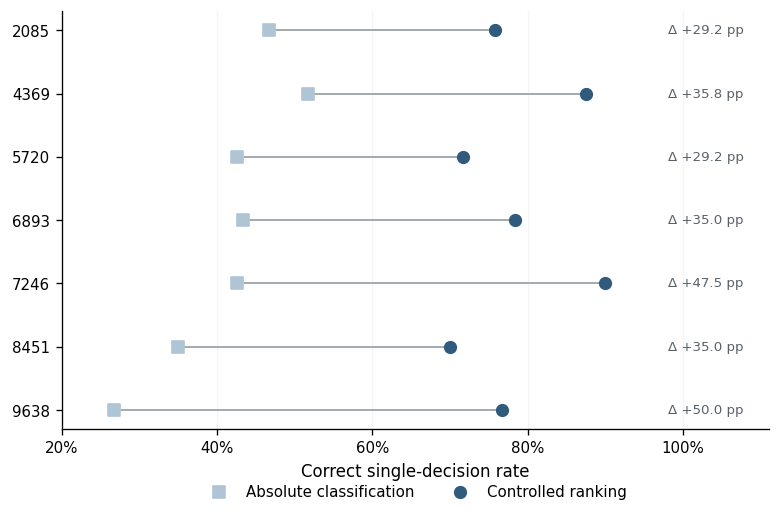

In [7]:
# Figure 1 — decision-rule comparison on each held-out password

plot = password_summary.copy()

fig, ax = plt.subplots(
    figsize=(
        7.6,
        4.9,
    )
)

y = np.arange(
    len(
        plot
    )
)

for (
    yi,
    row,
) in plot.iterrows():
    ax.plot(
        [
            100
            * row[
                "absolute_exact_one_correct_rate"
            ],
            100
            * row[
                "ranking_top1"
            ],
        ],
        [
            yi,
            yi,
        ],
        color=MID_GREY,
        linewidth=1.1,
        zorder=1,
    )


ax.scatter(
    100
    * plot[
        "absolute_exact_one_correct_rate"
    ],
    y,
    s=48,
    marker="s",
    color=LIGHT_BLUE,
    label="Absolute classification",
    zorder=3,
)

ax.scatter(
    100
    * plot[
        "ranking_top1"
    ],
    y,
    s=48,
    color=DARK_BLUE,
    label="Controlled ranking",
    zorder=3,
)


for (
    yi,
    row,
) in plot.iterrows():
    delta = (
        100
        * row[
            "ranking_minus_absolute_correct"
        ]
    )

    ax.text(
        98.0,
        yi,
        f"Δ {delta:+.1f} pp",
        ha="left",
        va="center",
        fontsize=8,
        color=DARK_GREY,
    )


ax.set_yticks(
    y
)

ax.set_yticklabels(
    plot[
        "password"
    ]
)

ax.invert_yaxis()

ax.set_xlim(
    20,
    111,
)

ax.set_xlabel(
    "Correct single-decision rate"
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, pos: f"{x:.0f}%"
    )
)

ax.grid(
    axis="x",
    alpha=0.13,
)

ax.legend(
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.10,
    ),
)

fig.subplots_adjust(
    bottom=0.17
)

save_figure(
    fig,
    "RQ11_Fig1_password_decision_rule",
)

plt.show()

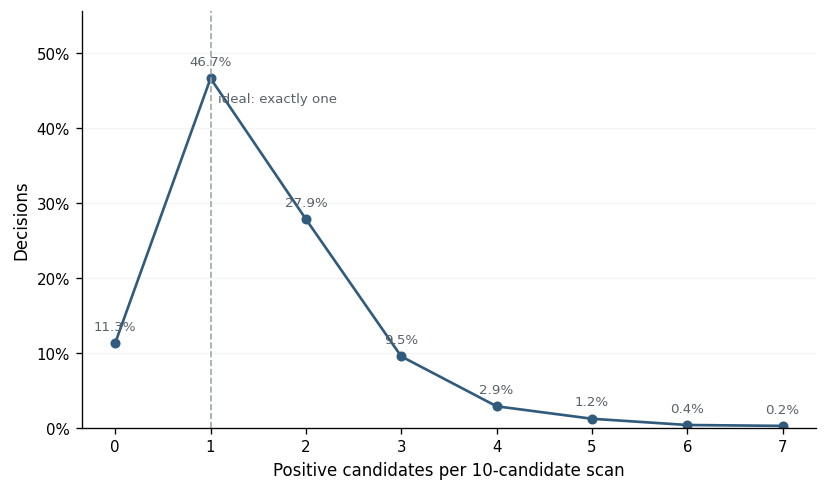

In [8]:
# Figure 2 — independent classification does not reliably return one candidate

positive_count_distribution = (
    decisions[
        "n_absolute_positives"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "n_positive_candidates"
    )
    .reset_index(
        name="n_decisions"
    )
)

positive_count_distribution[
    "rate"
] = (
    positive_count_distribution[
        "n_decisions"
    ]
    / len(
        decisions
    )
)

fig, ax = plt.subplots(
    figsize=(
        7.0,
        4.2,
    )
)

x = positive_count_distribution[
    "n_positive_candidates"
].to_numpy()

rates = (
    100
    * positive_count_distribution[
        "rate"
    ].to_numpy()
)

ax.plot(
    x,
    rates,
    marker="o",
    markersize=5,
    linewidth=1.6,
    color=DARK_BLUE,
)

ax.axvline(
    1,
    linestyle="--",
    linewidth=1,
    color=MID_GREY,
)

ax.text(
    1.08,
    max(
        rates
    )
    * 0.96,
    "ideal: exactly one",
    fontsize=8,
    color=DARK_GREY,
    va="top",
)

for (
    xi,
    value,
) in zip(
    x,
    rates,
):
    ax.annotate(
        f"{value:.1f}%",
        xy=(
            xi,
            value,
        ),
        xytext=(
            0,
            8,
        ),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color=DARK_GREY,
    )


ax.set_xlabel(
    "Positive candidates per 10-candidate scan"
)

ax.set_ylabel(
    "Decisions"
)

ax.set_xticks(
    np.arange(
        int(
            x.min()
        ),
        int(
            x.max()
        )
        + 1,
    )
)

ax.set_ylim(
    0,
    max(
        rates
    )
    + 9,
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda y, pos: f"{y:.0f}%"
    )
)

ax.grid(
    axis="y",
    alpha=0.13,
)

fig.tight_layout()

save_figure(
    fig,
    "RQ11_Fig2_absolute_positive_count",
)

positive_count_distribution.to_csv(
    RESULT_DIR
    / "RQ11_positive_count_distribution.csv",
    index=False,
)

plt.show()

## 6. Supporting result

The candidate-level score is not weak. Its AUROC is high. The failure is that an absolute threshold does not reliably convert that useful score into exactly one physical action.

This is why the reformulation is a decision-unit change rather than simply a claim that the old classifier had no signal.

In [9]:
support_metrics = pd.DataFrame([
    {
        "metric": (
            "Candidate AUROC"
        ),
        "value": candidate_metrics[
            "roc_auc"
        ],
    },
    {
        "metric": (
            "Candidate recall"
        ),
        "value": candidate_metrics[
            "recall"
        ],
    },
    {
        "metric": (
            "Exactly one positive"
        ),
        "value": overall[
            "absolute_exact_one_rate"
        ],
    },
    {
        "metric": (
            "Absolute correct"
        ),
        "value": overall[
            "absolute_exact_one_correct_rate"
        ],
    },
    {
        "metric": (
            "Ranking Top-1"
        ),
        "value": overall[
            "ranking_top1"
        ],
    },
])

support_metrics.to_csv(
    RESULT_DIR
    / "RQ11_supporting_metrics.csv",
    index=False,
)

display(
    support_metrics.round(
        4
    )
)

,metric,value
0,Candidate AUROC,0.9484
1,Candidate recall,0.8131
2,Exactly one positive,0.4667
3,Absolute correct,0.4119
4,Ranking Top-1,0.7857


## 7. Tables and result record

In [10]:
candidates.to_csv(
    RESULT_DIR
    / "RQ11_candidate_scores.csv",
    index=False,
)

decisions.to_csv(
    RESULT_DIR
    / "RQ11_decision_comparison.csv",
    index=False,
)

password_summary.to_csv(
    RESULT_DIR
    / "RQ11_password_summary.csv",
    index=False,
)


wheel_summary = (
    decisions.groupby(
        "wheel"
    )
    .agg(
        n_decisions=(
            "decision_uid",
            "size",
        ),
        absolute_exact_one_rate=(
            "absolute_exact_one",
            "mean",
        ),
        absolute_exact_one_correct_rate=(
            "absolute_exact_one_correct",
            "mean",
        ),
        absolute_zero_positive_rate=(
            "absolute_zero_positive",
            "mean",
        ),
        absolute_multiple_positive_rate=(
            "absolute_multiple_positive",
            "mean",
        ),
        ranking_top1=(
            "ranking_top1",
            "mean",
        ),
        ranking_top2=(
            "ranking_top2",
            "mean",
        ),
        ranking_top3=(
            "ranking_top3",
            "mean",
        ),
    )
    .reset_index()
)

wheel_summary.to_csv(
    RESULT_DIR
    / "RQ11_wheel_summary.csv",
    index=False,
)


pd.DataFrame([
    candidate_metrics
]).to_csv(
    RESULT_DIR
    / "RQ11_candidate_classification_metrics.csv",
    index=False,
)


pd.DataFrame([
    {
        "comparison": (
            "Controlled ranking Top-1 "
            "vs absolute exact-one-correct"
        ),
        "n_passwords": len(
            password_summary
        ),
        "statistic": float(
            paired_test.statistic
        ),
        "p_one_sided": float(
            paired_test.pvalue
        ),
        "mean_improvement_pp": float(
            100
            * password_summary[
                "ranking_minus_absolute_correct"
            ].mean()
        ),
        "median_improvement_pp": float(
            100
            * password_summary[
                "ranking_minus_absolute_correct"
            ].median()
        ),
        "ranking_better_passwords": int(
            (
                password_summary[
                    "ranking_minus_absolute_correct"
                ]
                > 0
            ).sum()
        ),
    }
]).to_csv(
    RESULT_DIR
    / "RQ11_paired_test.csv",
    index=False,
)


table1 = pd.DataFrame([
    {
        "Measure": (
            "Candidate AUROC"
        ),
        "Absolute classification": (
            f"{candidate_metrics['roc_auc']:.3f}"
        ),
        "Controlled ranking": "—",
    },
    {
        "Measure": (
            "Candidate recall"
        ),
        "Absolute classification": (
            f"{100 * candidate_metrics['recall']:.1f}%"
        ),
        "Controlled ranking": "—",
    },
    {
        "Measure": (
            "Exactly one candidate returned"
        ),
        "Absolute classification": (
            f"{100 * overall['absolute_exact_one_rate']:.1f}%"
        ),
        "Controlled ranking": "100.0%",
    },
    {
        "Measure": (
            "Correct single decision / Top-1"
        ),
        "Absolute classification": (
            f"{100 * overall['absolute_exact_one_correct_rate']:.1f}%"
        ),
        "Controlled ranking": (
            f"{100 * overall['ranking_top1']:.1f}%"
        ),
    },
    {
        "Measure": "Top-2",
        "Absolute classification": "—",
        "Controlled ranking": (
            f"{100 * overall['ranking_top2']:.1f}%"
        ),
    },
    {
        "Measure": "Top-3",
        "Absolute classification": "—",
        "Controlled ranking": (
            f"{100 * overall['ranking_top3']:.1f}%"
        ),
    },
])

table1.to_csv(
    RESULT_DIR
    / "RQ11_Table1_overall.csv",
    index=False,
)

with open(
    RESULT_DIR
    / "RQ11_Table1_overall.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table1.to_latex(
            index=False,
            escape=True,
        )
    )


table2 = password_summary.copy()

table2[
    "Absolute exact-one"
] = (
    100
    * table2[
        "absolute_exact_one_rate"
    ]
).map(
    lambda x: f"{x:.1f}%"
)

table2[
    "Absolute correct"
] = (
    100
    * table2[
        "absolute_exact_one_correct_rate"
    ]
).map(
    lambda x: f"{x:.1f}%"
)

table2[
    "Ranking Top-1"
] = (
    100
    * table2[
        "ranking_top1"
    ]
).map(
    lambda x: f"{x:.1f}%"
)

table2[
    "Improvement"
] = (
    100
    * table2[
        "ranking_minus_absolute_correct"
    ]
).map(
    lambda x: f"{x:+.1f} pp"
)

table2 = table2[
    [
        "password",
        "Absolute exact-one",
        "Absolute correct",
        "Ranking Top-1",
        "Improvement",
    ]
].rename(
    columns={
        "password": "Password",
    }
)

table2.to_csv(
    RESULT_DIR
    / "RQ11_Table2_passwords.csv",
    index=False,
)

with open(
    RESULT_DIR
    / "RQ11_Table2_passwords.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table2.to_latex(
            index=False,
            escape=True,
        )
    )

display(
    table1
)

display(
    table2
)

,Measure,Absolute classification,Controlled ranking
0,Candidate AUROC,0.948,—
1,Candidate recall,81.3%,—
2,Exactly one candidate returned,46.7%,100.0%
3,Correct single decision / Top-1,41.2%,78.6%
4,Top-2,—,90.4%
5,Top-3,—,95.5%


,Password,Absolute exact-one,Absolute correct,Ranking Top-1,Improvement
0,2085,49.2%,46.7%,75.8%,+29.2 pp
1,4369,55.0%,51.7%,87.5%,+35.8 pp
2,5720,54.2%,42.5%,71.7%,+29.2 pp
3,6893,48.3%,43.3%,78.3%,+35.0 pp
4,7246,45.0%,42.5%,90.0%,+47.5 pp
5,8451,40.8%,35.0%,70.0%,+35.0 pp
6,9638,34.2%,26.7%,76.7%,+50.0 pp


In [11]:
conclusion = {
    "research_question": (
        "Should the task be treated as independent absolute candidate classification "
        "or as controlled relative ranking within each 10-candidate scan?"
    ),
    "analysis_type": (
        "Decision-rule ablation using identical frozen LOPO candidate scores"
    ),
    "relation_to_RQ7": (
        "RQ7 changed the feature representation. RQ11 keeps the Absolute 695-D "
        "representation, model, folds and scores fixed and changes only the decision rule."
    ),
    "data": {
        "source": (
            "RQ7 Absolute leave-one-password-out candidate predictions"
        ),
        "passwords": [
            "2085",
            "4369",
            "5720",
            "6893",
            "7246",
            "8451",
            "9638",
        ],
        "n_decisions": 840,
        "n_candidates": 8400,
        "decision_size": 10,
    },
    "absolute_classification": {
        "decision_boundary": (
            "Logistic decision_function score >= 0"
        ),
        "candidate_roc_auc": candidate_metrics[
            "roc_auc"
        ],
        "candidate_average_precision": candidate_metrics[
            "average_precision"
        ],
        "candidate_precision": candidate_metrics[
            "precision"
        ],
        "candidate_recall": candidate_metrics[
            "recall"
        ],
        "candidate_f1": candidate_metrics[
            "f1"
        ],
        "candidate_balanced_accuracy": candidate_metrics[
            "balanced_accuracy"
        ],
        "exact_one_candidate_rate": overall[
            "absolute_exact_one_rate"
        ],
        "exact_one_correct_rate": overall[
            "absolute_exact_one_correct_rate"
        ],
        "zero_positive_rate": overall[
            "absolute_zero_positive_rate"
        ],
        "multiple_positive_rate": overall[
            "absolute_multiple_positive_rate"
        ],
    },
    "controlled_ranking": {
        "rule": (
            "Within each complete 10-candidate decision, sort the same scores and select the maximum."
        ),
        "top1": overall[
            "ranking_top1"
        ],
        "top2": overall[
            "ranking_top2"
        ],
        "top3": overall[
            "ranking_top3"
        ],
        "mean_true_rank": overall[
            "ranking_mean_true_rank"
        ],
        "single_decision_rate": 1.0,
    },
    "password_level_test": {
        "n_passwords": int(
            len(
                password_summary
            )
        ),
        "ranking_better_passwords": int(
            (
                password_summary[
                    "ranking_minus_absolute_correct"
                ]
                > 0
            ).sum()
        ),
        "mean_improvement_pp": float(
            100
            * password_summary[
                "ranking_minus_absolute_correct"
            ].mean()
        ),
        "median_improvement_pp": float(
            100
            * password_summary[
                "ranking_minus_absolute_correct"
            ].median()
        ),
        "wilcoxon_p_one_sided": float(
            paired_test.pvalue
        ),
    },
    "interpretation": (
        "The candidate score itself is strongly discriminative: candidate-level AUROC is "
        f"{candidate_metrics['roc_auc']:.3f}. However, independent threshold classification "
        "does not map cleanly onto the physical decision. It returns exactly one positive "
        f"candidate in only {100 * overall['absolute_exact_one_rate']:.1f}% of scans; "
        f"{100 * overall['absolute_zero_positive_rate']:.1f}% return none and "
        f"{100 * overall['absolute_multiple_positive_rate']:.1f}% return multiple candidates. "
        f"Only {100 * overall['absolute_exact_one_correct_rate']:.1f}% of scans therefore "
        "produce a unique correct absolute decision. Using the identical candidate scores as "
        f"a within-scan ranking raises Top-1 to {100 * overall['ranking_top1']:.1f}% and "
        "always returns one decision. Ranking is better on all seven held-out passwords "
        f"(one-sided paired Wilcoxon p = {paired_test.pvalue:.4f})."
    ),
    "limitation": (
        "The absolute-classification comparison uses the natural zero decision boundary of the "
        "balanced logistic score rather than tuning a separate threshold per password or scan. "
        "A calibrated threshold could change precision/recall, but any fixed independent threshold "
        "can still return zero or multiple candidates. Enforcing exactly one positive by adapting "
        "the threshold to the ten candidates would itself become a relative decision rule."
    ),
    "decision": (
        "Adopt the complete 10-candidate scan as the atomic decision unit. Preserve candidate "
        "scores, but interpret them by controlled within-scan ranking rather than requiring an "
        "absolute true/false threshold to produce one wheel-digit decision."
    ),
    "next_step": (
        "RQ12 formalises the dataset and grouping rules required to prevent the new ranking "
        "formulation from learning candidate-order, repeat or password shortcuts."
    ),
}

with open(
    RESULT_DIR
    / "RQ11_conclusion.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        conclusion,
        f,
        indent=2,
    )


run_info = {
    "notebook": (
        "11_RQ11_Absolute_vs_Controlled_Ranking.ipynb"
    ),
    "input": (
        "results/07_RQ7_Absolute_vs_Relative/RQ7_candidate_predictions.csv"
    ),
    "used_representation": (
        "Absolute"
    ),
    "score_provenance": (
        "Frozen RQ7 LOPO logistic decision scores; "
        "W1/W2/W4 and CW/CCW models separated."
    ),
    "absolute_rule": (
        "score >= 0 independently for each candidate"
    ),
    "ranking_rule": (
        "argmax / rank within each 10-candidate decision"
    ),
    "primary_inference": (
        "Password-level one-sided paired Wilcoxon: "
        "ranking Top-1 > absolute exact-one-correct rate."
    ),
}

with open(
    RESULT_DIR
    / "RQ11_run_info.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        run_info,
        f,
        indent=2,
    )


print(
    json.dumps(
        conclusion,
        indent=2,
    )
)

print(
    "\nSaved outputs:"
)

for path in sorted(
    RESULT_DIR.glob(
        "RQ11_*"
    )
):
    print(
        " -",
        path.name,
    )

{
  "research_question": "Should the task be treated as independent absolute candidate classification or as controlled relative ranking within each 10-candidate scan?",
  "analysis_type": "Decision-rule ablation using identical frozen LOPO candidate scores",
  "relation_to_RQ7": "RQ7 changed the feature representation. RQ11 keeps the Absolute 695-D representation, model, folds and scores fixed and changes only the decision rule.",
  "data": {
    "source": "RQ7 Absolute leave-one-password-out candidate predictions",
    "passwords": [
      "2085",
      "4369",
      "5720",
      "6893",
      "7246",
      "8451",
      "9638"
    ],
    "n_decisions": 840,
    "n_candidates": 8400,
    "decision_size": 10
  },
  "absolute_classification": {
    "decision_boundary": "Logistic decision_function score >= 0",
    "candidate_roc_auc": 0.9484123834719073,
    "candidate_average_precision": 0.7541050149199033,
    "candidate_precision": 0.5344287949921753,
    "candidate_recall": 0.813095